# *Breast Cancer Detection Using Deep Learning (Fuzzy)*

# 01 - Data Exploration

Purpose:
- Load raw breast thermogram images
- Visualize sample images
- Inspect image size, channels and intensity range
- Verify dataset structure

Dataset(s):
- DMR-IR

In [1]:
import sys, os

In [2]:
sys.path.append(os.path.abspath(".."))

In [3]:
from src.sch_cs import run_schcs
from src.preprocessing import run_preprocessing
from src.utils import base_path, dmr_ir_o, PRE_CFG, SCH_CFG

Config ready.
  PreprocessConfig(overlay_top_pct=0.08, overlay_left_pct=0.0, overlay_right_pct=0.0, colorbar_search_pct=0.15, colorbar_blue_thresh=200, bg_channel='green', bg_sum_thresh=30, crop_neck_pct=0.16, crop_stomach_pct=0.14, crop_armpit_pct=0.1, format_b_h=120, format_b_w=160, format_b_crop={'top': 18, 'bottom': 100, 'left': 0, 'right': 134})
  SchCsConfig(epsilon=35.0, min_region_px=20, edge_col_pct=0.08)


## SCH-CS

In [4]:
DMR_IR_PATH = base_path + dmr_ir_o

image_files = sorted([
    f for f in os.listdir(DMR_IR_PATH)
    if f.lower().endswith(('.jpg', '.png', '.jpeg'))
])
print(f'Found {len(image_files)} images:')
for i, f in enumerate(image_files):
    print(f'  [{i}] {f}')

Found 17 images:
  [0] TFRON_V11_31-10-2012_0.jpg
  [1] TFRON_V12_31-10-2012_0.jpg
  [2] TFRON_V13_31-10-2012_0.jpg
  [3] TFRON_V15_31-10-2012_0.jpg
  [4] TFRON_V16_31-10-2012_0.jpg
  [5] TFRON_V1_26-10-2012_0.jpg
  [6] TFRON_V243_12-3-2014_0.jpg
  [7] TFRON_V247_21-5-2014_0.jpg
  [8] TFRON_V2_30-10-2012_0.jpg
  [9] TFRON_V39_7-11-2012_0.jpg
  [10] TFRON_V4_30-10-2012_0.jpg
  [11] TFRON_V59_20-11-2012_0.jpg
  [12] TFRON_V5_30-10-2012_0.jpg
  [13] TFRON_V6_30-10-2012_0.jpg
  [14] TFRON_V7_31-10-2012_0.jpg
  [15] TFRON_V8_31-10-2012_0.jpg
  [16] TFRON_V9_31-10-2012_0.jpg


  PRE-PROCESSING: TFRON_V243_12-3-2014_0.jpg
[1.0] Loaded 480×640.
[1.1] FLIR overlay zeroed: top 38px.
[1.2] No colour bar detected.
[1.2] Calibration square removed: size=1px, bbox=(0×0), aspect=0.00.
[1.2] Calibration square removed: size=1px, bbox=(0×0), aspect=0.00.
[1.2] Calibration square removed: size=1px, bbox=(0×0), aspect=0.00.
[1.2] Calibration square removed: size=1px, bbox=(0×0), aspect=0.00.
[1.2] Calibration square removed: size=1px, bbox=(0×0), aspect=0.00.
[1.2] Calibration square removed: size=1px, bbox=(0×0), aspect=0.00.
[1.2] Calibration square removed: size=1px, bbox=(0×0), aspect=0.00.
[1.2] Calibration square removed: size=1px, bbox=(0×0), aspect=0.00.
[1.2] Calibration square removed: size=1px, bbox=(0×0), aspect=0.00.
[1.2] Calibration square removed: size=3px, bbox=(1×1), aspect=1.00.
[1.2] Calibration square removed: size=3px, bbox=(1×1), aspect=1.00.
[1.2] Calibration square removed: size=1px, bbox=(0×0), aspect=0.00.
[1.2] Calibration square removed: size

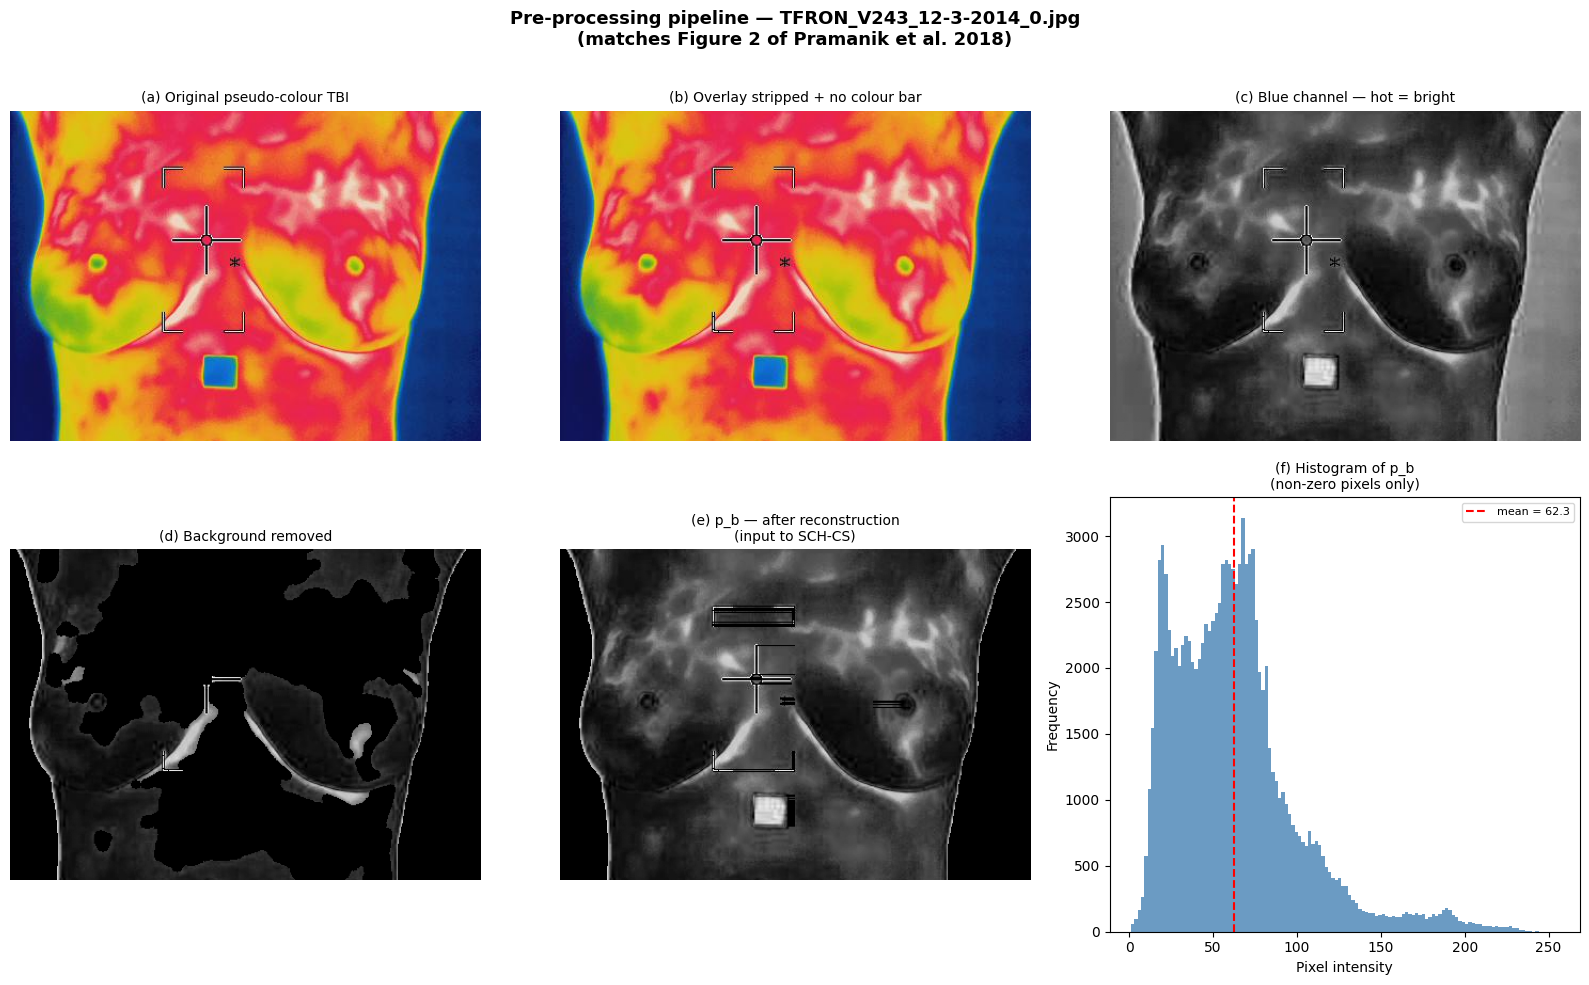


  SCH-CS: TFRON_V243_12-3-2014_0.jpg

[SCH 2.1] Building histogram...
  N=109330, R=242, m=N/R=451.78, peaks found=63

[SCH 2.2] Computing rho...
  r=22, V=1258.0, C=86.9, max_h=1732 at level 73
  rho=-431.85 (fallback to m) → rho_eff=451.78

[SCH 2.3] Computing t*...
  |A|=41, A range=[98,243], m(A)=171.10, alpha(A)=42.05, t*=129.05

[SCH 2.4] Computing th...
  m(p)=62.32, t*=129.05 → th = t* = 129.05

[SCH 2.5] Thresholding (th=129.05) and labelling...
  SR pixels=5846, regions total=94, after size filter=24

[CS 2.7] Weighted centroids for 24 regions...
  R(   1): centroid=(153.3,29.4), size=575px
  R(  14): centroid=(79.5,330.0), size=986px
  R(  15): centroid=(54.1,151.1), size=21px
  R(  17): centroid=(78.3,284.3), size=553px
  R(  19): centroid=(72.4,117.7), size=191px
  R(  22): centroid=(73.9,364.8), size=73px
  R(  34): centroid=(82.0,86.5), size=29px
  R(  40): centroid=(102.5,182.1), size=30px
  R(  44): centroid=(104.0,185.0), size=27px
  R(  46): centroid=(104.8,157.6), 

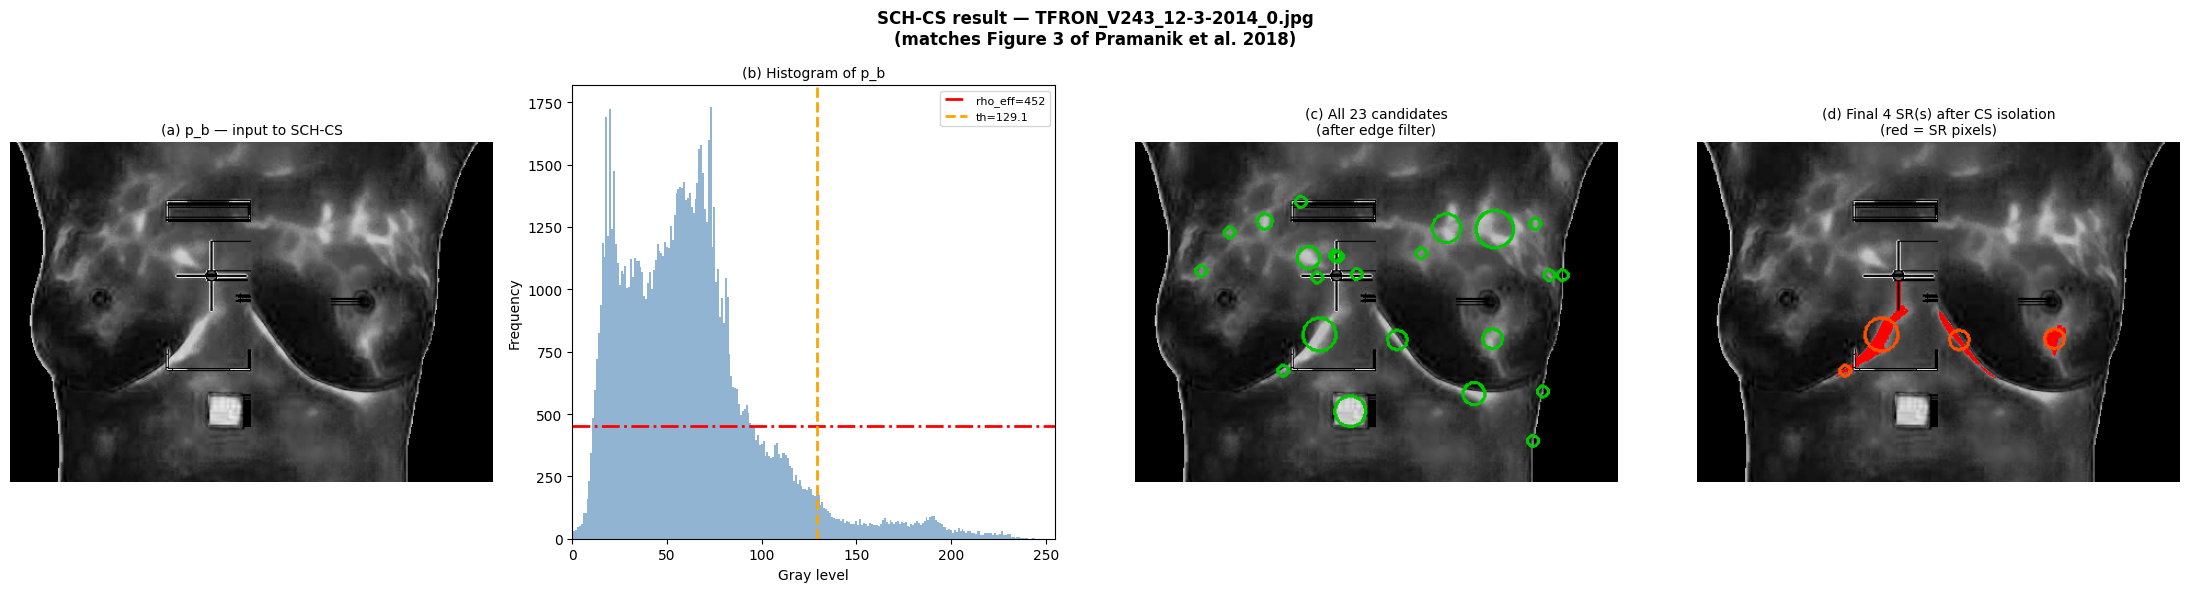


 Final SR summary:
  Label    Size(px)   Centroid(row,col)
  -------- ---------- --------------------
  65       718        (174.7, 168.4)
  67       284        (180.0, 239.0)
  69       259        (178.9, 326.3)
  79       45         (207.6, 135.3)

[Done] 4 SR(s) ready for DLPE Level Set.

━━━ Ready for DLPE Level Set ━━━
  pb shape      : (310, 441)
  Number of SRs : 4
  SR 1: label=65, size=718px, centroid=(174.7,168.4)
  SR 2: label=67, size=284px, centroid=(180.0,239.0)
  SR 3: label=69, size=259px, centroid=(178.9,326.3)
  SR 4: label=79, size=45px, centroid=(207.6,135.3)


In [5]:
IMAGE_INDEX = 6   # ← change this to try a different image
IMAGE_PATH  = os.path.join(DMR_IR_PATH, image_files[IMAGE_INDEX])

# ── Pre-processing ────────────────────────────────────────────────────────────
pre_result = run_preprocessing(IMAGE_PATH, cfg=PRE_CFG, visualize=True)

# ── SCH-CS ────────────────────────────────────────────────────────────────────
schcs_result = run_schcs(
    pb         = pre_result['pb'],
    cfg        = SCH_CFG,
    visualize  = True,
    image_name = pre_result['image_name']
)

# ── Output for DLPE ───────────────────────────────────────────────────────────
sr_regions = schcs_result['sr_regions']
pb         = pre_result['pb']

print('\n━━━ Ready for DLPE Level Set ━━━')
print(f'  pb shape      : {pb.shape}')
print(f'  Number of SRs : {len(sr_regions)}')
for i, sr in enumerate(sr_regions):
    X, Y = sr['centroid']
    print(f'  SR {i+1}: label={sr["label"]}, '
          f'size={sr["size"]}px, centroid=({X:.1f},{Y:.1f})')